<a href="https://colab.research.google.com/github/SuhanaS136/deep-learning/blob/main/RNN_for_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.6664 - loss: 0.5873 - val_accuracy: 0.8124 - val_loss: 0.4271
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.8550 - loss: 0.3441 - val_accuracy: 0.8204 - val_loss: 0.4585
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9079 - loss: 0.2408 - val_accuracy: 0.8306 - val_loss: 0.4131
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9487 - loss: 0.1465 - val_accuracy: 0.8130 - val_loss: 0.4691
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9807 - loss: 0.0678 - val_accuracy: 0.8100 - val_loss: 0.5848
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8072 - loss: 0.5830
Test Accuracy: 0.8071600198745728


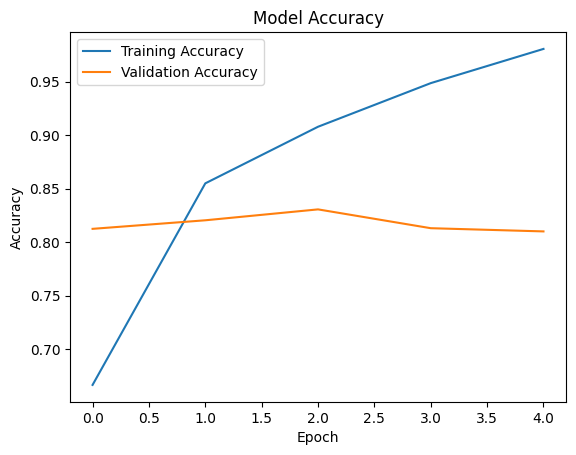

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=32))

model.add(SimpleRNN(32))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()